# 우양 샘플 데이터 발전량 예측 실험

자문전문가님이 제공한 샘플 데이터를 기준으로 발전량 예측 모델을 비교합니다.

목표:
1. 샘플 데이터 로드
2. 전문가 제공 feature 구조 기반 feature 생성
3. LightGBM / XGBoost / LSTM 모델 성능 비교
4. 가장 좋은 모델 선정

In [1553]:
# =========================
# 0. 라이브러리
# =========================
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

## 1. 데이터 불러오기

아래 코드가 현재 폴더에서 `260427_우양...csv` 파일을 자동으로 찾습니다.  
파일명을 바꿨다면 `csv_path`를 직접 수정하면 됩니다.

In [1554]:
# =========================
# 1. 데이터 불러오기
# =========================

csv_candidates = glob.glob("*.csv") + glob.glob("../*.csv") + glob.glob("./data/*.csv")
csv_candidates = [p for p in csv_candidates if "우양" in p or "wooyang" in p.lower()]

if len(csv_candidates) == 0:
    raise FileNotFoundError("우양 CSV 파일을 찾지 못했습니다. 이 노트북과 같은 폴더에 CSV를 넣어주세요.")

csv_path = csv_candidates[0]
print("사용 CSV:", csv_path)

df = pd.read_csv(csv_path, encoding="utf-8-sig")

print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

df.head()

사용 CSV: 260427_우양_2025년9월25일_2026년4월26일.csv
데이터 크기: (5126, 18)
컬럼 목록:
['V_SITE_ID', 'V_TIME', 'D_PVI_CAPA', 'D_PERIOD_GEN_KWH', 'D_TOT_GEN_KWH', 'D_TEMP', 'D_HUMIDITY', 'D_PRESSURE', 'D_DEW', 'D_UVI', 'D_CLOUDS', 'D_VISIBILITY', 'D_WIND_SPEED', 'D_WIND_DEG', 'V_GPS_Y', 'V_GPS_X', '__SRC__', 'TIME']


,V_SITE_ID,V_TIME,D_PVI_CAPA,D_PERIOD_GEN_KWH,D_TOT_GEN_KWH,D_TEMP,D_HUMIDITY,D_PRESSURE,D_DEW,D_UVI,D_CLOUDS,D_VISIBILITY,D_WIND_SPEED,D_WIND_DEG,V_GPS_Y,V_GPS_X,__SRC__,TIME
0,KR10025001,2025092510,968.375,105.20,463708.13,23.38,94.0,1019.0,22.36,0.0,100.0,6302.0,2.75,183.0,36.037267,126.689885,MASTER,2025092510
1,KR10025001,2025092511,968.375,225.53,463933.66,23.32,93.0,1019.0,22.12,0.0,100.0,10000.0,3.57,182.0,36.037267,126.689885,MASTER,2025092511
2,KR10025001,2025092512,968.375,235.00,464168.66,23.37,92.0,1019.0,22.00,0.0,100.0,10000.0,3.60,182.0,36.037267,126.689885,MASTER,2025092512
3,KR10025001,2025092513,968.375,146.07,464314.73,23.62,91.0,1019.0,22.06,0.0,100.0,10000.0,3.06,197.0,36.037267,126.689885,MASTER,2025092513
4,KR10025001,2025092514,968.375,183.46,464498.19,24.68,84.0,1018.0,21.79,0.0,100.0,10000.0,3.01,219.0,36.037267,126.689885,MASTER,2025092514


## 2. 시간 변환 및 기본 확인

- 예측 대상: `D_PERIOD_GEN_KWH`
- 시간 기준: `TIME` 또는 `V_TIME`

In [1555]:
# =========================
# 1. 데이터 불러오기
# =========================
import pandas as pd
import os

csv_path = "260427_우양_2025년9월25일_2026년4월26일.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"파일이 없습니다: {csv_path}")

print("사용 CSV:", csv_path)

try:
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
except:
    df = pd.read_csv(csv_path, encoding="cp949")

print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

df.head()

사용 CSV: 260427_우양_2025년9월25일_2026년4월26일.csv
데이터 크기: (5126, 18)
컬럼 목록:
['V_SITE_ID', 'V_TIME', 'D_PVI_CAPA', 'D_PERIOD_GEN_KWH', 'D_TOT_GEN_KWH', 'D_TEMP', 'D_HUMIDITY', 'D_PRESSURE', 'D_DEW', 'D_UVI', 'D_CLOUDS', 'D_VISIBILITY', 'D_WIND_SPEED', 'D_WIND_DEG', 'V_GPS_Y', 'V_GPS_X', '__SRC__', 'TIME']


,V_SITE_ID,V_TIME,D_PVI_CAPA,D_PERIOD_GEN_KWH,D_TOT_GEN_KWH,D_TEMP,D_HUMIDITY,D_PRESSURE,D_DEW,D_UVI,D_CLOUDS,D_VISIBILITY,D_WIND_SPEED,D_WIND_DEG,V_GPS_Y,V_GPS_X,__SRC__,TIME
0,KR10025001,2025092510,968.375,105.20,463708.13,23.38,94.0,1019.0,22.36,0.0,100.0,6302.0,2.75,183.0,36.037267,126.689885,MASTER,2025092510
1,KR10025001,2025092511,968.375,225.53,463933.66,23.32,93.0,1019.0,22.12,0.0,100.0,10000.0,3.57,182.0,36.037267,126.689885,MASTER,2025092511
2,KR10025001,2025092512,968.375,235.00,464168.66,23.37,92.0,1019.0,22.00,0.0,100.0,10000.0,3.60,182.0,36.037267,126.689885,MASTER,2025092512
3,KR10025001,2025092513,968.375,146.07,464314.73,23.62,91.0,1019.0,22.06,0.0,100.0,10000.0,3.06,197.0,36.037267,126.689885,MASTER,2025092513
4,KR10025001,2025092514,968.375,183.46,464498.19,24.68,84.0,1018.0,21.79,0.0,100.0,10000.0,3.01,219.0,36.037267,126.689885,MASTER,2025092514


## 3. 전문가 제공 feature 구조 생성

자문전문가님이 공유해주신 구조:
- 시간/계절: `H_SIN`, `H_COS`, `DOY_SIN`, `DOY_COS`
- 기상: `TEMP`, `HUMI`, `CLOU`, `WISP`, `WIDE_SIN`, `WIDE_COS`
- 태양 기하: `SUN_ELEV_CLIP`, `COS_ZEN`
- 강수: `PCP_MM`, `PCP_6H`, `SNO_24H`, `POP_PCT`
- 결측 플래그: `N_MISSING`, `MISS_TEMP`, `MISS_CLOU`, `MISS_WISP`, `MISS_WIDE`, `MISS_ASOS_ANY`

현재 샘플 데이터에 강수 컬럼이 없으므로 강수 feature는 0으로 대체합니다.

In [1556]:
# =========================
# Feature 생성 (우양 데이터 맞춤)
# =========================

import numpy as np
import pandas as pd

# -------------------------
# 1. 시간 컬럼 변환
# -------------------------
target_col = "D_PERIOD_GEN_KWH"
df["TIME"] = pd.to_datetime(df["V_TIME"].astype(str), format="%Y%m%d%H")
df = df.sort_values("TIME").reset_index(drop=True)

hour = df["TIME"].dt.hour
doy = df["TIME"].dt.dayofyear

# -------------------------
# 2. 설비용량
# -------------------------
df["CAPA"] = df["D_PVI_CAPA"]

# -------------------------
# 3. 시간 / 계절 feature
# -------------------------
df["H_SIN"] = np.sin(2 * np.pi * hour / 24)
df["H_COS"] = np.cos(2 * np.pi * hour / 24)

df["DOY_SIN"] = np.sin(2 * np.pi * doy / 365)
df["DOY_COS"] = np.cos(2 * np.pi * doy / 365)

# -------------------------
# 4. 기상 feature 매핑
# -------------------------
df["TEMP"] = df["D_TEMP"]
df["HUMI"] = df["D_HUMIDITY"]
df["CLOU"] = df["D_CLOUDS"]
df["WISP"] = df["D_WIND_SPEED"]

# -------------------------
# 5. 풍향 sin/cos 변환
# -------------------------
df["WIDE_SIN"] = np.sin(np.deg2rad(df["D_WIND_DEG"]))
df["WIDE_COS"] = np.cos(np.deg2rad(df["D_WIND_DEG"]))

# -------------------------
# 6. 태양 기하 feature
# 현재는 시간 기반 근사값
# -------------------------
df["SUN_ELEV_CLIP"] = np.maximum(0, np.sin(np.pi * (hour - 6) / 12))
df["COS_ZEN"] = df["SUN_ELEV_CLIP"]

# -------------------------
# 7. 일사량 proxy feature
# -------------------------
df["IRRADIANCE_PROXY"] = df["SUN_ELEV_CLIP"]

df["CLEARNESS_PROXY"] = 1 - (df["CLOU"] / 100)
df["CLEARNESS_PROXY"] = df["CLEARNESS_PROXY"].clip(0, 1)

df["EST_IRRADIANCE"] = df["IRRADIANCE_PROXY"] * df["CLEARNESS_PROXY"]
df["IRRADIANCE_X_CAPA"] = df["EST_IRRADIANCE"] * df["CAPA"]

# -------------------------
# 8. 강수 feature
# 현재 데이터에 강수 컬럼이 없으므로 0 처리
# -------------------------
df["PCP_MM"] = 0
df["PCP_6H"] = 0
df["SNO_24H"] = 0
df["POP_PCT"] = 0

# -------------------------
# 9. 발전량 패턴 feature
# -------------------------
df["GEN_NORMAL_PATTERN"] = np.exp(-((df["TIME"].dt.hour - 13) ** 2) / 18)

df["SEASONAL_SOLAR_PATTERN"] = df["GEN_NORMAL_PATTERN"] * df["DOY_SIN"].clip(lower=0)

df["WEATHER_ADJUSTED_PATTERN"] = (
    df["GEN_NORMAL_PATTERN"] * df["CLEARNESS_PROXY"]
)

df["EXPECTED_GEN_PROXY"] = (
    df["WEATHER_ADJUSTED_PATTERN"] * df["CAPA"]
)

df["GEN_LAG_1"] = df[target_col].shift(1)
df["GEN_LAG_2"] = df[target_col].shift(2)
df["GEN_LAG_3"] = df[target_col].shift(3)

df["GEN_ROLL_MEAN_3"] = df[target_col].shift(1).rolling(3).mean()
df["GEN_ROLL_MEAN_6"] = df[target_col].shift(1).rolling(6).mean()

# -------------------------
# 10. 결측 플래그 생성
# -------------------------
df["MISS_TEMP"] = df["D_TEMP"].isna().astype(int)
df["MISS_CLOU"] = df["D_CLOUDS"].isna().astype(int)
df["MISS_WISP"] = df["D_WIND_SPEED"].isna().astype(int)
df["MISS_WIDE"] = df["D_WIND_DEG"].isna().astype(int)

df["N_MISSING"] = df[
    ["MISS_TEMP", "MISS_CLOU", "MISS_WISP", "MISS_WIDE"]
].sum(axis=1)

df["MISS_ASOS_ANY"] = (df["N_MISSING"] > 0).astype(int)

# -------------------------
# 11. 확인
# -------------------------
print("Feature 생성 완료")

check_cols = [
    "TIME",
    "H_SIN", "H_COS", "DOY_SIN", "DOY_COS",
    "TEMP", "HUMI", "CLOU", "WISP",
    "WIDE_SIN", "WIDE_COS",
    "SUN_ELEV_CLIP", "COS_ZEN",
    "IRRADIANCE_PROXY", "CLEARNESS_PROXY",
    "EST_IRRADIANCE", "IRRADIANCE_X_CAPA",
    "GEN_NORMAL_PATTERN", "WEATHER_ADJUSTED_PATTERN",
    "EXPECTED_GEN_PROXY",
    "N_MISSING", "MISS_ASOS_ANY",
    "CAPA"
]

print(df[check_cols].head())
print("총 생성 feature 수:", len(check_cols) - 1)

Feature 생성 완료
                 TIME         H_SIN     H_COS   DOY_SIN  DOY_COS   TEMP  HUMI  \
0 2025-09-25 10:00:00  5.000000e-01 -0.866025 -0.995105 -0.09882  23.38  94.0   
1 2025-09-25 11:00:00  2.588190e-01 -0.965926 -0.995105 -0.09882  23.32  93.0   
2 2025-09-25 12:00:00  1.224647e-16 -1.000000 -0.995105 -0.09882  23.37  92.0   
3 2025-09-25 13:00:00 -2.588190e-01 -0.965926 -0.995105 -0.09882  23.62  91.0   
4 2025-09-25 14:00:00 -5.000000e-01 -0.866025 -0.995105 -0.09882  24.68  84.0   

    CLOU  WISP  WIDE_SIN  ...  IRRADIANCE_PROXY  CLEARNESS_PROXY  \
0  100.0  2.75 -0.052336  ...          0.866025              0.0   
1  100.0  3.57 -0.034899  ...          0.965926              0.0   
2  100.0  3.60 -0.034899  ...          1.000000              0.0   
3  100.0  3.06 -0.292372  ...          0.965926              0.0   
4  100.0  3.01 -0.629320  ...          0.866025              0.0   

   EST_IRRADIANCE  IRRADIANCE_X_CAPA  GEN_NORMAL_PATTERN  \
0             0.0             

In [1557]:
# =========================
# NASA 일사량 추가 - 시간 미스매치 보정 버전
# =========================

import requests
import pandas as pd

lat = 36.0185
lon = 126.6953

start_date = df["TIME"].min().strftime("%Y%m%d")
end_date = df["TIME"].max().strftime("%Y%m%d")

url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    f"?parameters=ALLSKY_SFC_SW_DWN"
    f"&community=RE"
    f"&longitude={lon}"
    f"&latitude={lat}"
    f"&start={start_date}"
    f"&end={end_date}"
    f"&format=JSON"
    f"&time-standard=UTC"
)

res = requests.get(url)
data = res.json()

irr = data["properties"]["parameter"]["ALLSKY_SFC_SW_DWN"]

df_irr = pd.DataFrame(list(irr.items()), columns=["TIME_KEY", "IRRADIANCE"])

# NASA UTC 시간으로 파싱
df_irr["TIME_UTC"] = pd.to_datetime(df_irr["TIME_KEY"], format="%Y%m%d%H", utc=True)

# UTC → 한국시간 변환
df_irr["TIME"] = df_irr["TIME_UTC"].dt.tz_convert("Asia/Seoul").dt.tz_localize(None)

df_irr = df_irr[["TIME", "IRRADIANCE"]]

# 결측/이상값 처리
df_irr["IRRADIANCE"] = df_irr["IRRADIANCE"].replace(-999, 0)
df_irr["IRRADIANCE"] = df_irr["IRRADIANCE"].fillna(0)

# IRRADIANCE 시간 1시간 shift
df_irr["TIME"] = df_irr["TIME"] + pd.Timedelta(hours=1)

df = df.drop(columns=["IRRADIANCE"], errors="ignore")

# 다시 merge
df = df.merge(
    df_irr[["TIME", "IRRADIANCE"]],
    on="TIME",
    how="left"
)

df["IRRADIANCE"] = df["IRRADIANCE"].fillna(0)

print(df[["TIME", "IRRADIANCE"]].head(10))
print("IRRADIANCE 결측:", df["IRRADIANCE"].isna().sum())

                 TIME  IRRADIANCE
0 2025-09-25 10:00:00      101.25
1 2025-09-25 11:00:00      159.32
2 2025-09-25 12:00:00      238.85
3 2025-09-25 13:00:00      197.70
4 2025-09-25 14:00:00      369.58
5 2025-09-25 15:00:00      338.83
6 2025-09-25 16:00:00      294.20
7 2025-09-25 17:00:00      164.50
8 2025-09-25 18:00:00       58.92
9 2025-09-25 19:00:00        3.35
IRRADIANCE 결측: 0


In [1558]:
print("df TIME")
print(df["TIME"].head(5))

print("\ndf_irr TIME")
print(df_irr["TIME"].head(5))

df[["TIME", "IRRADIANCE"]].iloc[100:120]

df[["TIME", "IRRADIANCE"]].head(50)

df TIME
0   2025-09-25 10:00:00
1   2025-09-25 11:00:00
2   2025-09-25 12:00:00
3   2025-09-25 13:00:00
4   2025-09-25 14:00:00
Name: TIME, dtype: datetime64[ns]

df_irr TIME
0   2025-09-25 10:00:00
1   2025-09-25 11:00:00
2   2025-09-25 12:00:00
3   2025-09-25 13:00:00
4   2025-09-25 14:00:00
Name: TIME, dtype: datetime64[ns]


,TIME,IRRADIANCE
0,2025-09-25 10:00:00,101.25
1,2025-09-25 11:00:00,159.32
2,2025-09-25 12:00:00,238.85
3,2025-09-25 13:00:00,197.70
4,2025-09-25 14:00:00,369.58
5,2025-09-25 15:00:00,338.83
6,2025-09-25 16:00:00,294.20
7,2025-09-25 17:00:00,164.50
8,2025-09-25 18:00:00,58.92
9,2025-09-25 19:00:00,3.35


In [1559]:
print(df["TIME"].min(), df["TIME"].max())
print(df_irr["TIME"].min(), df_irr["TIME"].max())

2025-09-25 10:00:00 2026-04-26 23:00:00
2025-09-25 10:00:00 2026-04-27 09:00:00


In [1560]:
# =========================
# 발전량 이상치 제거 - 비교용 df_clip 생성
# =========================

df_clip = df.copy()

target_col = "D_PERIOD_GEN_KWH"

lower = df_clip[target_col].quantile(0.01)
upper = df_clip[target_col].quantile(0.99)

df_clip[target_col] = df_clip[target_col].clip(lower=lower, upper=upper)

print("df_clip 생성 완료")

df_clip 생성 완료


## 4. Feature / Target 설정

이번 실험은 전문가 feature 구조를 우선으로 사용합니다.  
`CAPA`는 발전소 설비 용량 정보로 추가했습니다.

In [1561]:
# =========================
# 4. Feature / Target 설정
# =========================


df["IRRADIANCE"] = df["IRRADIANCE"].fillna(0)

feature_cols = [
    # 시간/계절
    "H_SIN", "H_COS", "DOY_SIN", "DOY_COS",

    # 기상
    "TEMP", "HUMI", "CLOU", "WISP",
    "WIDE_SIN", "WIDE_COS",

    # 태양
    "SUN_ELEV_CLIP", "COS_ZEN",

    # 강수
    "PCP_MM", "PCP_6H", "SNO_24H", "POP_PCT",

    # 결측
    "N_MISSING", "MISS_TEMP", "MISS_CLOU",
    "MISS_WISP", "MISS_WIDE", "MISS_ASOS_ANY",

    # 설비
    "CAPA",

    # 일사량 proxy
    "IRRADIANCE_PROXY",
    "CLEARNESS_PROXY",
    "EST_IRRADIANCE",
    "IRRADIANCE_X_CAPA",

    # 발전 패턴
    "GEN_NORMAL_PATTERN",
    "SEASONAL_SOLAR_PATTERN",
    "WEATHER_ADJUSTED_PATTERN",
    "EXPECTED_GEN_PROXY",

    "IRRADIANCE",

    "GEN_LAG_1",
    "GEN_LAG_2",
    "GEN_LAG_3",
    "GEN_ROLL_MEAN_3",
    "GEN_ROLL_MEAN_6",
]

df_model = df_clip[["TIME"] + feature_cols_23 + [target_col]].copy()

df_model = df_model.dropna(subset=[target_col]).reset_index(drop=True)

for col in feature_cols_23:
    df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model[feature_cols_23]
y = df_model[target_col]

print("X:", X.shape)
print("y:", y.shape)

X: (5126, 23)
y: (5126,)


In [1562]:
print(df.columns)

Index(['V_SITE_ID', 'V_TIME', 'D_PVI_CAPA', 'D_PERIOD_GEN_KWH',
       'D_TOT_GEN_KWH', 'D_TEMP', 'D_HUMIDITY', 'D_PRESSURE', 'D_DEW', 'D_UVI',
       'D_CLOUDS', 'D_VISIBILITY', 'D_WIND_SPEED', 'D_WIND_DEG', 'V_GPS_Y',
       'V_GPS_X', '__SRC__', 'TIME', 'CAPA', 'H_SIN', 'H_COS', 'DOY_SIN',
       'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS',
       'SUN_ELEV_CLIP', 'COS_ZEN', 'IRRADIANCE_PROXY', 'CLEARNESS_PROXY',
       'EST_IRRADIANCE', 'IRRADIANCE_X_CAPA', 'PCP_MM', 'PCP_6H', 'SNO_24H',
       'POP_PCT', 'GEN_NORMAL_PATTERN', 'SEASONAL_SOLAR_PATTERN',
       'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'GEN_LAG_1',
       'GEN_LAG_2', 'GEN_LAG_3', 'GEN_ROLL_MEAN_3', 'GEN_ROLL_MEAN_6',
       'MISS_TEMP', 'MISS_CLOU', 'MISS_WISP', 'MISS_WIDE', 'N_MISSING',
       'MISS_ASOS_ANY', 'IRRADIANCE'],
      dtype='object')


In [1563]:
# ===== Feature_20 =====

feature_cols_20 = [
    # 시간 / 계절
    "H_SIN", "H_COS",
    "DOY_SIN", "DOY_COS",

    # 기상
    "TEMP", "HUMI", "CLOU", "WISP",

    # 풍향
    "WIDE_SIN", "WIDE_COS",

    # 태양 위치
    "SUN_ELEV_CLIP", "COS_ZEN",

    # 설비
    "CAPA",

    # 일사량 proxy
    "IRRADIANCE_PROXY",
    "EST_IRRADIANCE",
    "IRRADIANCE_X_CAPA",

    "IRRADIANCE",

    # 발전 패턴
    "EXPECTED_GEN_PROXY",

    # 과거 발전량
    "GEN_LAG_1",
    "GEN_ROLL_MEAN_3",
    "GEN_ROLL_MEAN_6",
]

target_col = "D_PERIOD_GEN_KWH"

df_model_20 = df[["TIME"] + feature_cols_20 + [target_col]].copy()

df_model_20 = df_model_20.dropna(subset=[target_col]).reset_index(drop=True)

for col in feature_cols_20:
    df_model_20[col] = df_model_20[col].fillna(df_model_20[col].median())

X_20 = df_model_20[feature_cols_20]
y_20 = df_model_20[target_col]

print("X_20:", X_20.shape)

X_20: (5126, 21)


In [1564]:
# ===== No Lag Feature =====

feature_cols_no_lag = [
    # 시간 / 계절
    "H_SIN", "H_COS",
    "DOY_SIN", "DOY_COS",

    # 기상
    "TEMP", "HUMI", "CLOU", "WISP",
    "WIDE_SIN", "WIDE_COS",

    # 태양 위치
    "SUN_ELEV_CLIP", "COS_ZEN",

    # 설비
    "CAPA",

    # 일사량 (현재는 사용 가능)
    "IRRADIANCE",

    # proxy
    "IRRADIANCE_PROXY",
    "EST_IRRADIANCE",
    "IRRADIANCE_X_CAPA",

    # 발전 추정
    "EXPECTED_GEN_PROXY",
]

target_col = "D_PERIOD_GEN_KWH"

df_model_nl = df[["TIME"] + feature_cols_no_lag + [target_col]].copy()

df_model_nl = df_model_nl.dropna(subset=[target_col]).reset_index(drop=True)

for col in feature_cols_no_lag:
    df_model_nl[col] = df_model_nl[col].fillna(df_model_nl[col].median())

X_nl = df_model_nl[feature_cols_no_lag]
y_nl = df_model_nl[target_col]

print("X_nl:", X_nl.shape)

X_nl: (5126, 18)


In [1565]:
final_features = [
    # ===== 시간 / 계절 =====
    "H_SIN", "H_COS",
    "DOY_SIN", "DOY_COS",

    # ===== 기상 =====
    "TEMP", "HUMI", "CLOU", "WISP",
    "WIDE_SIN", "WIDE_COS",

    # ===== 태양 =====
    "SUN_ELEV_CLIP", "COS_ZEN",

    # ===== 설비 =====
    "CAPA",

    # ===== 핵심 일사량 =====
    "IRRADIANCE",            # ⭐ 실제 값
    "EST_IRRADIANCE",        # ⭐ 추정
    "IRRADIANCE_X_CAPA",     # ⭐ 발전량과 직접 연결

    # ===== 보조 proxy =====
    "IRRADIANCE_PROXY",

    # ===== 발전 패턴 =====
    "EXPECTED_GEN_PROXY",

    # ===== 과거 발전량 (핵심) =====
    "GEN_LAG_1",
    "GEN_LAG_2",             # ⭐ 추가 (중요도 높았음)
    "GEN_ROLL_MEAN_3",
    "GEN_ROLL_MEAN_6",
]

# ===== Feature_22 데이터 생성 =====

target_col = "D_PERIOD_GEN_KWH"

df_model_22 = df[["TIME"] + final_features + [target_col]].copy()

df_model_22 = df_model_22.dropna(subset=[target_col]).reset_index(drop=True)

for col in final_features:
    df_model_22[col] = df_model_22[col].fillna(df_model_22[col].median())

X_22 = df_model_22[final_features]
y_22 = df_model_22[target_col]

print("X_22:", X_22.shape)
print("y_22:", y_22.shape)

X_22: (5126, 22)
y_22: (5126,)


In [1566]:
# ===== Feature 23 =====
feature_cols_23 = [
    "H_SIN", "H_COS",
    "DOY_SIN", "DOY_COS",

    "TEMP", "HUMI", "CLOU", "WISP",
    "WIDE_SIN", "WIDE_COS",

    "SUN_ELEV_CLIP", "COS_ZEN",

    "IRRADIANCE",
    "EST_IRRADIANCE",
    "IRRADIANCE_PROXY",
    "IRRADIANCE_X_CAPA",

    "CAPA",

    "SEASONAL_SOLAR_PATTERN",
    "WEATHER_ADJUSTED_PATTERN",
    "EXPECTED_GEN_PROXY",

    "GEN_LAG_1",
    "GEN_LAG_2",
    "GEN_ROLL_MEAN_6",
]


# ===== Feature 25 =====
feature_cols_25 = feature_cols_23 + [
    "CLEARNESS_PROXY",
    "GEN_ROLL_MEAN_3",
]

In [1567]:
# ===== Feature 23 =====
df_model_23 = df[["TIME"] + feature_cols_23 + [target_col]].copy()
df_model_23 = df_model_23.dropna(subset=[target_col]).reset_index(drop=True)

for col in feature_cols_23:
    df_model_23[col] = df_model_23[col].fillna(df_model_23[col].median())

X_23 = df_model_23[feature_cols_23]
y_23 = df_model_23[target_col]


# ===== Feature 25 =====
df_model_25 = df[["TIME"] + feature_cols_25 + [target_col]].copy()
df_model_25 = df_model_25.dropna(subset=[target_col]).reset_index(drop=True)

for col in feature_cols_25:
    df_model_25[col] = df_model_25[col].fillna(df_model_25[col].median())

X_25 = df_model_25[feature_cols_25]
y_25 = df_model_25[target_col]

In [1568]:
# =========================
# 5. 분포 불일치 대응용 데이터 증강
# =========================

#df_aug = df_model.copy()

#np.random.seed(42)

# -------------------------
# 1. 예보 오차 시뮬레이션
# -------------------------

# 온도 예보 오차
#df_aug["TEMP"] = df_aug["TEMP"] + np.random.normal(0, 1.0, len(df_aug))

# 습도 예보 오차
#df_aug["HUMI"] = df_aug["HUMI"] + np.random.normal(0, 5.0, len(df_aug))

# 운량 예보 오차
#df_aug["CLOU"] = df_aug["CLOU"] + np.random.normal(0, 10.0, len(df_aug))

# 풍속 예보 오차
#df_aug["WISP"] = df_aug["WISP"] + np.random.normal(0, 0.8, len(df_aug))

# 값 범위 보정
#df_aug["HUMI"] = df_aug["HUMI"].clip(0, 100)
#df_aug["CLOU"] = df_aug["CLOU"].clip(0, 100)
#df_aug["WISP"] = df_aug["WISP"].clip(lower=0)

# -------------------------
# 2. 예보 결측 상황 시뮬레이션
# -------------------------

#missing_rate = 0.05

#for col, flag_col in [
   # ("TEMP", "MISS_TEMP"),
  #  ("CLOU", "MISS_CLOU"),
 #   ("WISP", "MISS_WISP"),
#]:
 #   mask = np.random.rand(len(df_aug)) < missing_rate
  #  df_aug.loc[mask, col] = np.nan
   # df_aug.loc[mask, flag_col] = 1

# 결측 개수 다시 계산
#df_aug["N_MISSING"] = df_aug[
 #   ["MISS_TEMP", "MISS_CLOU", "MISS_WISP", "MISS_WIDE"]
#].sum(axis=1)

#df_aug["MISS_ASOS_ANY"] = (df_aug["N_MISSING"] > 0).astype(int)

# -------------------------
# 3. 결측값 보정
# -------------------------
#for col in ["TEMP", "HUMI", "CLOU", "WISP"]:
 #   df_aug[col] = df_aug[col].fillna(df_aug[col].median())

# -------------------------
# 4. 증강 데이터 기준 X, y 생성
# -------------------------

#X_aug = df_aug[feature_cols]
#y_aug = df_aug[target_col]

#print("분포 불일치 대응 데이터 생성 완료")
#print("X_aug:", X_aug.shape)
#print("y_aug:", y_aug.shape)
#print("결측 개수:", X_aug.isna().sum().sum())

## 5. 시간 순서 기준 Train/Test 분할

시계열 데이터이므로 랜덤 분할이 아니라 앞 80%를 학습, 뒤 20%를 테스트로 사용합니다.

In [1569]:
# 패널 feature 개수에 맞춤
df_model_cut = df_model.iloc[:3640]

X = df_model_cut[feature_cols_23]
y = df_model_cut[target_col]

# 분리
X_train = X.iloc[:2898]
X_val = X.iloc[2898:2898+409]
X_test = X.iloc[2898+409:]

y_train = y.iloc[:2898]
y_val = y.iloc[2898:2898+409]
y_test = y.iloc[2898+409:]

In [1570]:
# image 컬럼 제거
panel_train = panel_train.drop(columns=["image"], errors="ignore")
panel_val = panel_val.drop(columns=["image"], errors="ignore")
panel_test = panel_test.drop(columns=["image"], errors="ignore")

# 패널 feature 결합
X_train_final = pd.concat(
    [X_train.reset_index(drop=True),
     panel_train.reset_index(drop=True)],
    axis=1
)

X_val_final = pd.concat(
    [X_val.reset_index(drop=True),
     panel_val.reset_index(drop=True)],
    axis=1
)

X_test_final = pd.concat(
    [X_test.reset_index(drop=True),
     panel_test.reset_index(drop=True)],
    axis=1
)

print(X_train_final.shape)
print(X_val_final.shape)
print(X_test_final.shape)

(2898, 33)
(409, 33)
(333, 33)


In [1571]:
# =========================
# Wooyang test 데이터 저장
# =========================

wooyang_test_df = X_test_final.copy()

# TIME도 동일한 333개 구간으로 맞춤
time_test = df_model_cut["TIME"].iloc[2898+409:]

wooyang_test_df.insert(0, "TIME", time_test.values)

# 실제값 포함
wooyang_test_df["ACTUAL_GEN_KWH"] = y_test.values

# 저장
wooyang_test_df.to_csv(
    "wooyang_test_data_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_test_data_panel.csv 저장 완료")
print(wooyang_test_df.shape)

✅ wooyang_test_data_panel.csv 저장 완료
(333, 35)


In [1572]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(random_state=42)

# 패널 feature 포함 데이터로 재학습
lgb_model.fit(X_train_final, y_train)

# 검증 성능 확인
val_pred_lgb = lgb_model.predict(X_val_final)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_lgb))
val_mae = mean_absolute_error(y_val, val_pred_lgb)

print("Validation RMSE:", val_rmse)
print("Validation MAE:", val_mae)

Validation RMSE: 59.8394403930059
Validation MAE: 28.938310606224338


In [1573]:
# =========================
# test 데이터 / merged 결과 재생성
# =========================

# test 구간 TIME 333개로 맞추기
time_test = df_model_cut["TIME"].iloc[2898+409:]

# 예측값도 X_test_final 기준으로 다시 생성
y_pred_lgb = lgb_model.predict(X_test_final)

# test 데이터 저장
wooyang_test_df = X_test_final.copy()
wooyang_test_df.insert(0, "TIME", time_test.values)

wooyang_test_df.to_csv(
    "wooyang_test_data_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

# 예측 + 실제값 포함 결과 저장
merged_df = X_test_final.copy()
merged_df.insert(0, "TIME", time_test.values)
merged_df["PREDICTION"] = y_pred_lgb
merged_df["ACTUAL"] = y_test.values

merged_df.to_csv(
    "wooyang_merged_result_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

print("재생성 완료")
print("X_test_final:", X_test_final.shape)
print("time_test:", len(time_test))
print("prediction:", len(y_pred_lgb))
print("merged:", merged_df.shape)

재생성 완료
X_test_final: (333, 33)
time_test: 333
prediction: 333
merged: (333, 36)


In [1574]:
# =========================
# 1.2 패널별 발전량 이상 감지
# =========================

# 1) 예측 오차 계산
merged_df["ERROR"] = abs(
    merged_df["ACTUAL"] - merged_df["PREDICTION"]
)

# 2) 이상 기준값 설정
threshold = (
    merged_df["ERROR"].mean()
    + 2 * merged_df["ERROR"].std()
)

# 3) 이상 라벨 생성
merged_df["ANOMALY"] = (
    merged_df["ERROR"] > threshold
).astype(int)

print("Threshold:", threshold)
print(merged_df["ANOMALY"].value_counts())

Threshold: 148.36625971928635
ANOMALY
0    309
1     24
Name: count, dtype: int64


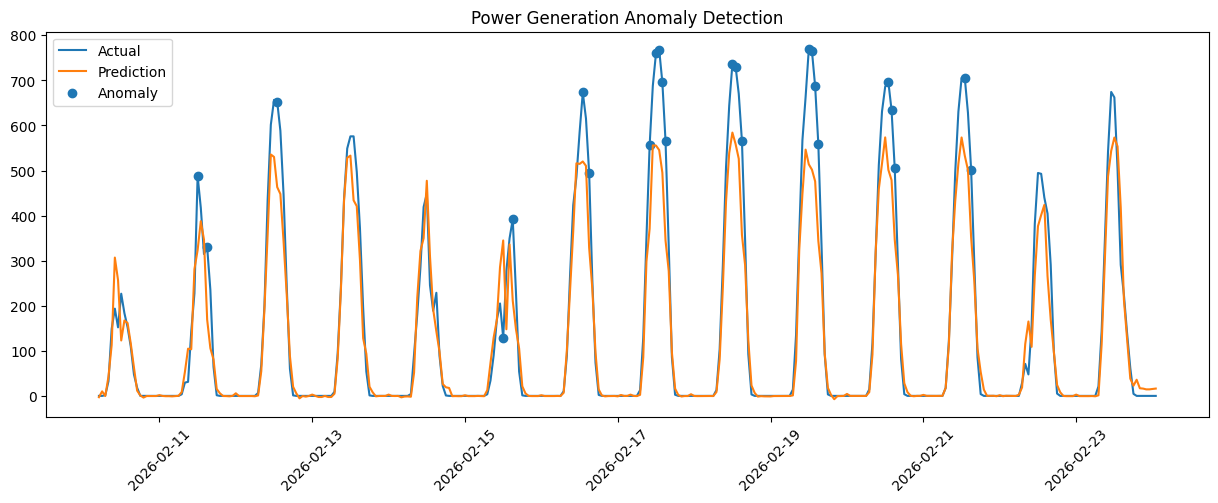

In [1575]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(merged_df["TIME"], merged_df["ACTUAL"], label="Actual")
plt.plot(merged_df["TIME"], merged_df["PREDICTION"], label="Prediction")

anomaly_df = merged_df[merged_df["ANOMALY"] == 1]

plt.scatter(
    anomaly_df["TIME"],
    anomaly_df["ACTUAL"],
    label="Anomaly"
)

plt.legend()
plt.xticks(rotation=45)
plt.title("Power Generation Anomaly Detection")
plt.show()

In [1576]:
panel_cols = [
    "dust_coverage_ratio",
    "snow_coverage_ratio",
    "bird_dropping_count",
    "physical_damage_count",
    "max_defect_confidence",
    "cls_normal",
    "cls_dust",
    "cls_snow",
    "cls_bird",
    "cls_damage"
]

anomaly_analysis = merged_df.groupby("ANOMALY")[panel_cols].mean()

display(anomaly_analysis)

,dust_coverage_ratio,snow_coverage_ratio,bird_dropping_count,physical_damage_count,max_defect_confidence,cls_normal,cls_dust,cls_snow,cls_bird,cls_damage
ANOMALY,,,,,,,,,,
0,0.034256,0.010603,-0.032004,0.041999,0.462219,0.0,0.200647,0.042071,0.003236,0.288026
1,0.022489,0.005355,0.039192,-0.037752,0.354533,0.0,0.166667,0.000000,0.000000,0.250000


In [1577]:
merged_df.to_csv(
    "wooyang_anomaly_result_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_anomaly_result_panel.csv 저장 완료")
print(merged_df.shape)

✅ wooyang_anomaly_result_panel.csv 저장 완료
(333, 38)


In [1578]:
anomaly_only = merged_df[merged_df["ANOMALY"] == 1][
    ["TIME", "ACTUAL", "PREDICTION", "ERROR"]
].sort_values("ERROR", ascending=False)

display(anomaly_only.head(20))

,TIME,ACTUAL,PREDICTION,ERROR
224,2026-02-19 13:00:00,764.37,501.843858,262.526142
223,2026-02-19 12:00:00,769.17,513.819887,255.350113
176,2026-02-17 13:00:00,768.08,545.460385,222.619615
178,2026-02-17 15:00:00,564.70,344.573660,220.126340
127,2026-02-15 12:00:00,128.79,344.863924,216.073924
226,2026-02-19 15:00:00,558.16,343.768125,214.391875
225,2026-02-19 14:00:00,686.54,475.943361,210.596639
202,2026-02-18 15:00:00,565.26,357.377062,207.882938
175,2026-02-17 12:00:00,760.53,555.478344,205.051656
177,2026-02-17 14:00:00,695.54,495.165925,200.374075


In [1579]:
anomaly_only.to_csv(
    "wooyang_anomaly_top20_panel.csv",
    index=False,
    encoding="utf-8-sig"
)

In [1580]:
# =========================
# 6. 평가 함수
# =========================

def evaluate_model(name, y_true, y_pred):
    y_true_arr = np.asarray(y_true).reshape(-1)
    y_pred_arr = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true_arr, y_pred_arr)
    rmse = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
    r2 = r2_score(y_true_arr, y_pred_arr)
    nrmse = rmse / np.mean(y_true_arr)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "nRMSE": nrmse
    }

## 6. LightGBM 학습

In [1581]:
# =========================
# 7. LightGBM
# =========================
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from lightgbm import LGBMRegressor

    lgb_model = LGBMRegressor(
        objective="regression_l1", 
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=15,
        num_leaves=5,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=0.5,
        random_state=42,
        verbose=-1
    )

    lgb_model.fit(X_train_final, y_train)

    y_pred_lgb = lgb_model.predict(X_test_final)
    val_pred_lgb = lgb_model.predict(X_val_final)
    result_lgb = evaluate_model("LightGBM", y_test, y_pred_lgb)

    for key, value in result_lgb.items():
        print(f"{key}: {value}")

except ModuleNotFoundError:
    result_lgb = None
    y_pred_lgb = None
    print("LightGBM이 설치되어 있지 않습니다.")
    print("설치 코드: pip install lightgbm")

Model: LightGBM
MAE: 26.105750280673874
RMSE: 50.05365229580678
R2: 0.9511057010347606
nRMSE: 0.3379891272904616


## 7. XGBoost 학습

In [1582]:
# =========================
# 8. XGBoost
# =========================

try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        objective="reg:squarederror",
        eval_metric="rmse"
    )

    xgb_model.fit(X_train, y_train)

    y_pred_xgb = xgb_model.predict(X_test)
    result_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb)

    print(result_xgb)

except ModuleNotFoundError:
    result_xgb = None
    y_pred_xgb = None
    print("XGBoost가 설치되어 있지 않습니다.")
    print("설치 코드: pip install xgboost")

{'Model': 'XGBoost', 'MAE': 33.48743446490225, 'RMSE': np.float64(62.96366334507803), 'R2': 0.9226310585034145, 'nRMSE': np.float64(0.42516445152187543)}


## 8. LSTM 학습

데이터 수가 많지 않아 LSTM은 LightGBM/XGBoost보다 불리할 수 있습니다.  
그래도 비교 실험용으로 실행합니다.

In [1583]:
# =========================
# 9. LSTM
# =========================
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(np.array(y_train).reshape(-1, 1))
    y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1, 1))

    def create_sequences(X_arr, y_arr, time_steps=12):
        Xs, ys = [], []
        for i in range(len(X_arr) - time_steps):
            Xs.append(X_arr[i:i + time_steps])
            ys.append(y_arr[i + time_steps])
        return np.array(Xs), np.array(ys)

    time_steps = 12

    X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train_scaled, time_steps)
    X_test_lstm, y_test_lstm = create_sequences(X_test_scaled, y_test_scaled, time_steps)

    lstm_model = Sequential([
        LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    lstm_model.compile(optimizer="adam", loss="mae")

    lstm_model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=30,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

    y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)
    y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
    y_test_lstm_actual = scaler_y.inverse_transform(y_test_lstm)

    result_lstm = evaluate_model("LSTM", y_test_lstm_actual, y_pred_lstm)

    print(result_lstm)

    # =========================
# 앙상블 모델
# =========================


except ModuleNotFoundError:
    result_lstm = None
    y_pred_lstm = None
    print("TensorFlow가 설치되어 있지 않습니다.")
    print("설치 코드: pip install tensorflow")

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1248 - val_loss: 0.0704
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0743 - val_loss: 0.0496
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0658 - val_loss: 0.0448
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0598 - val_loss: 0.0410
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0518 - val_loss: 0.0560
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0501 - val_loss: 0.0413
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0485 - val_loss: 0.0565
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0486 - val_loss: 0.0534
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0465 - val_loss: 0.0405
Epoch 10/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0448 - val_loss: 0.0461
Epoch 11/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0457 - val_loss: 0.0435
Epoch 12/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0

In [1584]:
# =========================
# 앙상블 모델
# =========================

# LSTM 예측 길이에 맞추기
lstm_len = len(y_pred_lstm)

y_test_ens = np.array(y_test)[-lstm_len:]

y_pred_lgb_ens = np.array(y_pred_lgb)[-lstm_len:]
y_pred_xgb_ens = np.array(y_pred_xgb)[-lstm_len:]
y_pred_lstm_ens = np.array(y_pred_lstm).reshape(-1)

# 앙상블 1: LightGBM + LSTM
y_pred_ensemble_lgb_lstm = (y_pred_lgb_ens + y_pred_lstm_ens) / 2

# 앙상블 2: XGBoost + LSTM
y_pred_ensemble_xgb_lstm = (y_pred_xgb_ens + y_pred_lstm_ens) / 2

# 앙상블 3: 전체 평균
y_pred_ensemble_all = (
    y_pred_lgb_ens + y_pred_xgb_ens + y_pred_lstm_ens
) / 3

result_ensemble_lgb_lstm = evaluate_model(
    "Ensemble_LGBM_LSTM", y_test_ens, y_pred_ensemble_lgb_lstm
)

result_ensemble_xgb_lstm = evaluate_model(
    "Ensemble_XGB_LSTM", y_test_ens, y_pred_ensemble_xgb_lstm
)

result_ensemble_all = evaluate_model(
    "Ensemble_All", y_test_ens, y_pred_ensemble_all
)

print(result_ensemble_lgb_lstm)
print(result_ensemble_xgb_lstm)
print(result_ensemble_all)

{'Model': 'Ensemble_LGBM_LSTM', 'MAE': 43.23966974809509, 'RMSE': np.float64(93.20233241061594), 'R2': 0.835612028567048, 'nRMSE': np.float64(0.6224286639690353)}
{'Model': 'Ensemble_XGB_LSTM', 'MAE': 41.45352376011302, 'RMSE': np.float64(89.81797898088509), 'R2': 0.8473337521248838, 'nRMSE': np.float64(0.5998270988667176)}
{'Model': 'Ensemble_All', 'MAE': 25.28372724420861, 'RMSE': np.float64(60.45783689555957), 'R2': 0.9308293775426958, 'nRMSE': np.float64(0.403752670904991)}


## 9. 성능 비교 및 최종 모델 선정

In [1585]:
# =========================
# 10. 모델 성능 비교 (앙상블 포함)
# =========================

results_list = [
    r for r in [
        result_lgb,
        result_xgb,
        result_lstm,
        result_ensemble_lgb_lstm,
        result_ensemble_xgb_lstm,
        result_ensemble_all,
        result_nl
    ]
    if r is not None
]

if len(results_list) == 0:
    raise ValueError("학습 완료된 모델이 없습니다.")

results = pd.DataFrame(results_list)

# RMSE 기준 추천 (태양광은 RMSE 중요)
results = results.sort_values("RMSE").reset_index(drop=True)

results

,Model,MAE,RMSE,R2,nRMSE
0,LightGBM,26.105750,50.053652,0.951106,0.337989
1,Ensemble_All,25.283727,60.457837,0.930829,0.403753
2,XGBoost,33.487434,62.963663,0.922631,0.425164
3,Ensemble_XGB_LSTM,41.453524,89.817979,0.847334,0.599827
4,Ensemble_LGBM_LSTM,43.239670,93.202332,0.835612,0.622429
5,LightGBM_NO_LAG,53.823023,98.252725,0.871977,0.507688
6,LSTM,99.639286,199.509395,0.246743,1.332374


In [1586]:
# =========================
# 🔥 Lag 제거 모델 (실서비스용)
# =========================

result_nl = None

from lightgbm import LGBMRegressor

# 1. df_model에 실제 존재하는 feature만 사용
missing_cols = [col for col in feature_cols if col not in df_model.columns]

print("df_model에 없는 컬럼 개수:", len(missing_cols))
print("df_model에 없는 컬럼:", missing_cols)

feature_cols_valid = [col for col in feature_cols if col in df_model.columns]

print("사용 가능한 feature 개수:", len(feature_cols_valid))
print(feature_cols_valid)

# 2. Lag / Rolling feature 찾기
lag_features = [
    col for col in feature_cols_valid
    if ("LAG" in col.upper()) or ("ROLL" in col.upper())
]

print("제거할 lag/rolling feature 개수:", len(lag_features))
print("제거할 lag/rolling feature:", lag_features)

# 3. Lag / Rolling 제거 feature 생성
feature_cols_no_lag = [
    col for col in feature_cols_valid
    if col not in lag_features
]

print("lag 제거 후 feature 개수:", len(feature_cols_no_lag))
print(feature_cols_no_lag)

# 4. 데이터 생성
X_no_lag = df_model[feature_cols_no_lag]
y_no_lag = df_model[target_col]

# 5. 동일 split 유지
X_train_nl = X_no_lag.iloc[:split_idx]
X_test_nl = X_no_lag.iloc[split_idx:]

y_train_nl = y_no_lag.iloc[:split_idx]
y_test_nl = y_no_lag.iloc[split_idx:]

# 6. 모델 학습
lgb_model_nl = LGBMRegressor(
    random_state=42,
    objective="regression_l1"
)

lgb_model_nl.fit(X_train_nl, y_train_nl)

# 7. 예측
y_pred_nl = lgb_model_nl.predict(X_test_nl)

# 8. 평가
result_nl = evaluate_model("LightGBM_NO_LAG", y_test_nl, y_pred_nl)

print(result_nl)

df_model에 없는 컬럼 개수: 14
df_model에 없는 컬럼: ['PCP_MM', 'PCP_6H', 'SNO_24H', 'POP_PCT', 'N_MISSING', 'MISS_TEMP', 'MISS_CLOU', 'MISS_WISP', 'MISS_WIDE', 'MISS_ASOS_ANY', 'CLEARNESS_PROXY', 'GEN_NORMAL_PATTERN', 'GEN_LAG_3', 'GEN_ROLL_MEAN_3']
사용 가능한 feature 개수: 23
['H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN', 'CAPA', 'IRRADIANCE_PROXY', 'EST_IRRADIANCE', 'IRRADIANCE_X_CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'IRRADIANCE', 'GEN_LAG_1', 'GEN_LAG_2', 'GEN_ROLL_MEAN_6']
제거할 lag/rolling feature 개수: 3
제거할 lag/rolling feature: ['GEN_LAG_1', 'GEN_LAG_2', 'GEN_ROLL_MEAN_6']
lag 제거 후 feature 개수: 20
['H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN', 'CAPA', 'IRRADIANCE_PROXY', 'EST_IRRADIANCE', 'IRRADIANCE_X_CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'IRRADIANCE']
{'Mode

In [1587]:
# =========================
# 🔥 Lag 제거 + 일사량 추가 모델
# =========================

result_nli = None

from lightgbm import LGBMRegressor

# 1. df_model에 실제 존재하는 feature만 사용
feature_cols_valid = [col for col in feature_cols if col in df_model.columns]

missing_cols = [col for col in feature_cols if col not in df_model.columns]
print("df_model에 없는 컬럼 개수:", len(missing_cols))
print("df_model에 없는 컬럼:", missing_cols)

# 2. Lag / Rolling feature 제거
lag_features = [
    col for col in feature_cols_valid
    if ("LAG" in col.upper()) or ("ROLL" in col.upper())
]

feature_cols_no_lag = [
    col for col in feature_cols_valid
    if col not in lag_features
]

# 3. IRRADIANCE 추가
if "IRRADIANCE" in df_model.columns:
    if "IRRADIANCE" not in feature_cols_no_lag:
        feature_cols_no_lag.append("IRRADIANCE")
else:
    print("⚠️ IRRADIANCE 컬럼이 df_model에 없습니다. 일사량 없이 진행합니다.")

# 4. 최종적으로 한 번 더 존재 컬럼만 필터링
feature_cols_no_lag = [col for col in feature_cols_no_lag if col in df_model.columns]

print("제거할 lag/rolling feature 개수:", len(lag_features))
print("제거할 lag/rolling feature:", lag_features)

print("최종 feature 개수:", len(feature_cols_no_lag))
print(feature_cols_no_lag)

# 5. 데이터 구성
X_no_lag_irr = df_model[feature_cols_no_lag]
y_no_lag_irr = df_model[target_col]

# 6. 동일 split 유지
X_train_nli = X_no_lag_irr.iloc[:split_idx]
X_test_nli = X_no_lag_irr.iloc[split_idx:]

y_train_nli = y_no_lag_irr.iloc[:split_idx]
y_test_nli = y_no_lag_irr.iloc[split_idx:]

# 7. 모델 학습
lgb_model_nli = LGBMRegressor(
    random_state=42,
    objective="regression_l1"
)

lgb_model_nli.fit(X_train_nli, y_train_nli)

# 8. 예측
y_pred_nli = lgb_model_nli.predict(X_test_nli)

# 9. 평가
result_nli = evaluate_model("LightGBM_NO_LAG_IRRADIANCE", y_test_nli, y_pred_nli)

print(result_nli)

df_model에 없는 컬럼 개수: 14
df_model에 없는 컬럼: ['PCP_MM', 'PCP_6H', 'SNO_24H', 'POP_PCT', 'N_MISSING', 'MISS_TEMP', 'MISS_CLOU', 'MISS_WISP', 'MISS_WIDE', 'MISS_ASOS_ANY', 'CLEARNESS_PROXY', 'GEN_NORMAL_PATTERN', 'GEN_LAG_3', 'GEN_ROLL_MEAN_3']
제거할 lag/rolling feature 개수: 3
제거할 lag/rolling feature: ['GEN_LAG_1', 'GEN_LAG_2', 'GEN_ROLL_MEAN_6']
최종 feature 개수: 20
['H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU', 'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN', 'CAPA', 'IRRADIANCE_PROXY', 'EST_IRRADIANCE', 'IRRADIANCE_X_CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN', 'EXPECTED_GEN_PROXY', 'IRRADIANCE']
{'Model': 'LightGBM_NO_LAG_IRRADIANCE', 'MAE': 53.82302306267767, 'RMSE': np.float64(98.25272468758736), 'R2': 0.8719769317333483, 'nRMSE': np.float64(0.5076879981899041)}


In [1588]:
compare_no_lag = pd.DataFrame([
    result_nl,
    result_nli
]).sort_values("RMSE").reset_index(drop=True)

compare_no_lag

,Model,MAE,RMSE,R2,nRMSE
0,LightGBM_NO_LAG,53.823023,98.252725,0.871977,0.507688
1,LightGBM_NO_LAG_IRRADIANCE,53.823023,98.252725,0.871977,0.507688


In [1589]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor

def evaluate_model(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = LGBMRegressor(random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    nrmse = rmse / (y_test.max() - y_test.min())

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "nRMSE": nrmse
    }

results = []

# full feature
results.append(evaluate_model(X, y, "Full_Feature"))

# 20개 feature
results.append(evaluate_model(X_20, y_20, "Feature_20"))

# no lag feature
results.append(evaluate_model(X_nl, y_nl, "No_Lag"))

results.append(evaluate_model(X_22, y_22, "Feature_22"))
results.append(evaluate_model(X_23, y_23, "Feature_23"))
results.append(evaluate_model(X_25, y_25, "Feature_25"))

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="RMSE")

results_df

,Model,MAE,RMSE,R2,nRMSE
0,Full_Feature,27.960726,56.764120,0.935783,0.073799
4,Feature_23,37.771936,65.501924,0.944562,0.073897
1,Feature_20,41.787663,65.733068,0.944170,0.074158
5,Feature_25,38.090494,65.803966,0.944050,0.074238
3,Feature_22,42.187053,67.210771,0.941632,0.075825
2,No_Lag,67.604331,109.289185,0.845669,0.123297


In [1590]:
# =========================
# 🔥 병합 CSV 생성 (최종 전달용)
# =========================

# 1. test feature 복사
merged_df = X_test.copy()

# 2. TIME 추가
merged_df.insert(0, "TIME", time_test.values)

# 3. 예측값 추가
merged_df["PREDICTION"] = y_pred_lgb

# 4. (선택) 실제값도 같이 넣기
merged_df["ACTUAL"] = y_test.values

# 5. 저장
merged_df.to_csv(
    "wooyang_merged_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ wooyang_merged_result.csv 저장 완료")
print(merged_df.head())

✅ wooyang_merged_result.csv 저장 완료
                    TIME     H_SIN         H_COS  DOY_SIN   DOY_COS  TEMP  \
3307 2026-02-10 05:00:00  0.965926  2.588190e-01  0.64863  0.761104 -0.62   
3308 2026-02-10 06:00:00  1.000000  6.123234e-17  0.64863  0.761104 -1.05   
3309 2026-02-10 07:00:00  0.965926 -2.588190e-01  0.64863  0.761104 -0.88   
3310 2026-02-10 08:00:00  0.866025 -5.000000e-01  0.64863  0.761104 -0.82   
3311 2026-02-10 09:00:00  0.707107 -7.071068e-01  0.64863  0.761104 -0.36   

      HUMI   CLOU  WISP  WIDE_SIN  ...  IRRADIANCE_X_CAPA     CAPA  \
3307  72.0  100.0  1.55  0.190809  ...           0.000000  968.375   
3308  80.0   75.0  2.36  0.292372  ...           0.000000  968.375   
3309  79.0   80.0  2.41  0.422618  ...          50.126779  968.375   
3310  82.0   85.0  2.41  0.766044  ...          72.628125  968.375   
3311  80.0   90.0  2.18  0.927184  ...          68.474453  968.375   

      SEASONAL_SOLAR_PATTERN  WEATHER_ADJUSTED_PATTERN  EXPECTED_GEN_PROXY  \
3307

In [1591]:
merged_df.columns

Index(['TIME', 'H_SIN', 'H_COS', 'DOY_SIN', 'DOY_COS', 'TEMP', 'HUMI', 'CLOU',
       'WISP', 'WIDE_SIN', 'WIDE_COS', 'SUN_ELEV_CLIP', 'COS_ZEN',
       'IRRADIANCE', 'EST_IRRADIANCE', 'IRRADIANCE_PROXY', 'IRRADIANCE_X_CAPA',
       'CAPA', 'SEASONAL_SOLAR_PATTERN', 'WEATHER_ADJUSTED_PATTERN',
       'EXPECTED_GEN_PROXY', 'GEN_LAG_1', 'GEN_LAG_2', 'GEN_ROLL_MEAN_6',
       'PREDICTION', 'ACTUAL'],
      dtype='object')

In [1592]:
irr_cols = [col for col in merged_df.columns if "IRRADIANCE" in col]
print(irr_cols)

['IRRADIANCE', 'EST_IRRADIANCE', 'IRRADIANCE_PROXY', 'IRRADIANCE_X_CAPA']


In [1593]:
# =========================
# 11. 최종 모델 선정
# =========================

best_model_name = results_df.iloc[0]["Model"]

print("최종 선정 모델:", best_model_name)
print(results_df.iloc[0])

최종 선정 모델: Full_Feature
Model    Full_Feature
MAE         27.960726
RMSE         56.76412
R2           0.935783
nRMSE        0.073799
Name: 0, dtype: object


In [1594]:
print("train NaN:", X_train_final.isna().sum().sum())
print("val NaN:", X_val_final.isna().sum().sum())
print("test NaN:", X_test_final.isna().sum().sum())
print("train:", X_train_final.shape, y_train.shape)
print("val:", X_val_final.shape, y_val.shape)
print("test:", X_test_final.shape, y_test.shape)

train NaN: 0
val NaN: 0
test NaN: 0
train: (2898, 33) (2898,)
val: (409, 33) (409,)
test: (333, 33) (333,)


In [1595]:
print(X_test.shape)

(333, 23)


## 10. Feature Importance

트리 기반 모델 중 LightGBM이 실행된 경우 feature importance를 확인합니다.

In [1596]:
# =========================
# 12. Feature Importance
# =========================

if result_lgb is not None:
    importance_df = pd.DataFrame({
        "feature": X_train_final.columns,
        "importance": lgb_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importance_df.head(20))
else:
    print("LightGBM 결과가 없어 feature importance를 표시할 수 없습니다.")

,feature,importance
20,GEN_LAG_1,691
0,H_SIN,630
1,H_COS,591
18,WEATHER_ADJUSTED_PATTERN,489
22,GEN_ROLL_MEAN_6,378
6,CLOU,269
21,GEN_LAG_2,135
19,EXPECTED_GEN_PROXY,127
13,EST_IRRADIANCE,119
2,DOY_SIN,104


## 11. 예측 결과 저장

In [1597]:
# =========================
# 13. 예측 결과 저장
# =========================

pred_df = pd.DataFrame({
    "TIME": time_test.reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
})

if y_pred_lgb is not None:
    pred_df["Pred_LightGBM"] = y_pred_lgb

if y_pred_xgb is not None:
    pred_df["Pred_XGBoost"] = y_pred_xgb

# LSTM은 time_steps만큼 테스트 앞부분이 빠지므로 별도 저장
if result_lstm is not None:
    lstm_pred_df = pd.DataFrame({
        "TIME": time_test.iloc[time_steps:].reset_index(drop=True),
        "Actual": y_test_lstm_actual.reshape(-1),
        "Pred_LSTM": y_pred_lstm.reshape(-1)
    })
    lstm_pred_df.to_csv("wooyang_lstm_prediction_result.csv", index=False, encoding="utf-8-sig")

pred_df.to_csv("wooyang_prediction_result.csv", index=False, encoding="utf-8-sig")
results_df.to_csv("wooyang_model_comparison.csv", index=False, encoding="utf-8-sig")

print("저장 완료:")
print("- wooyang_prediction_result.csv")
print("- wooyang_model_comparison.csv")
if result_lstm is not None:
    print("- wooyang_lstm_prediction_result.csv")

pred_df.head()

저장 완료:
- wooyang_prediction_result.csv
- wooyang_model_comparison.csv
- wooyang_lstm_prediction_result.csv


,TIME,Actual,Pred_LightGBM,Pred_XGBoost
0,2026-02-10 05:00:00,0.00,-0.000110,-1.325267
1,2026-02-10 06:00:00,0.00,0.072377,-3.471225
2,2026-02-10 07:00:00,1.61,2.407707,-5.595468
3,2026-02-10 08:00:00,32.78,46.013990,68.952629
4,2026-02-10 09:00:00,148.67,86.654367,130.466446


In [1598]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2898, 23)
(409, 23)
(333, 23)


In [1599]:
import pandas as pd

panel_train = pd.read_csv("panel_features_train.csv")
panel_val = pd.read_csv("panel_features_val.csv")
panel_test = pd.read_csv("panel_features_test.csv")

print(panel_train.shape)
print(panel_val.shape)
print(panel_test.shape)

(2898, 11)
(409, 11)
(333, 11)


In [1600]:
print(panel_train["image"].head())

0    1-10-_jpg.rf.4c2db0f05c823f19f26f91dfde6e0130.jpg
1    1-100-_jpg.rf.05ad637368518c4accfbcd09c0645f6e...
2    1-100-_jpg.rf.249cfc5a3a5ced7f330bd1965ae8792e...
3    1-100-_jpg.rf.efb7fea4ca4d08c2f2fac9ce69ee9dc6...
4    1-102-_jpg.rf.5b090b64fbfcd73e26307016037cf9bd...
Name: image, dtype: object


## 12. 모델 저장

성능 비교 후 최종 모델만 저장해도 됩니다.  
아래 코드는 실행된 모델을 모두 저장합니다.

In [1601]:
# =========================
# 14. 모델 저장
# =========================

import joblib

if result_lgb is not None:
    joblib.dump(lgb_model, "wooyang_lightgbm_model.pkl")

if result_xgb is not None:
    joblib.dump(xgb_model, "wooyang_xgboost_model.pkl")

if result_lstm is not None:
    lstm_model.save("wooyang_lstm_model.h5")

print("모델 저장 완료")

모델 저장 완료
